# Machine Learning Group Project - Group AO
Group members:
- Filippo Deluchi 71064
- Giacomo Castiglioni 73411
- Pietro Franchi 73019
- Simone Capata 74777
- Riccardo Borella 73022
- Francesco Ciorciolini 73166

# 1. Business Case - Predictive Pricing Model

For the execution of this group project, we position ourselves as a mid-range used car dealer interested in predicting the optimal pricing for selling their portfolio of mid-range used cars. The goal of the dealer is to maximize sales margins, minimize the time-to-sale, and perform inventory planning (scheduling vehicle purchases and sales in advance) by identifying the ideal price point and selling window.

In this business context, our goal is to build a predictive model that acts as a helpful tool for determining pricing decisions. To develop this model, we will be utilizing a dataset based on historical used car listings in Great Britain. In this predictive pricing model, the dependent variable is Price: we aim to predict the average listing price for a specific type of car based on features such as car brand, mileage, and age.

### Importing Libraries

In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm  # OLS summary (p-values, confidence intervals)
import glob
import os
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

### Merging different datasets into one master dataframe

In [179]:
path = './data' 
all_files = glob.glob(os.path.join(path, "*.csv"))
df_list = []

for filename in all_files:
    df_temp = pd.read_csv(filename)
    brand_name = os.path.basename(filename).replace('.csv', '')
    df_temp['brand'] = brand_name
    df_list.append(df_temp)

# Concatenate everything into one Master Dataframe
master_df = pd.concat(df_list, axis=0, ignore_index=True)

# Save the Master File 
master_df.to_csv('master_car_listings.csv', index=False)
print(f"Master file created. Total observations: {len(master_df)}")
    
# Standardize column names
master_df.columns = master_df.columns.str.lower()
print(f" Load successful: {master_df.shape[0]} rows, {master_df.shape[1]} columns.")
display(master_df.head(30))
print(f"Total observations in master_df: {len(master_df)}")

Master file created. Total observations: 99187
 Load successful: 99187 rows, 11 columns.


,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,brand,tax(£)
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi,NaN
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi,NaN
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi,NaN
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi,NaN
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi,NaN
5,A1,2016,13900,Automatic,32260,Petrol,30.0,58.9,1.4,audi,NaN
6,A6,2016,13250,Automatic,76788,Diesel,30.0,61.4,2.0,audi,NaN
7,A4,2016,11750,Manual,75185,Diesel,20.0,70.6,2.0,audi,NaN
8,A3,2015,10200,Manual,46112,Petrol,20.0,60.1,1.4,audi,NaN
9,A1,2016,12000,Manual,22451,Petrol,30.0,55.4,1.4,audi,NaN


Total observations in master_df: 99187


# 2. Data Cleaning

### Removing Duplicate Rows

In [180]:
# Identify and remove duplicate rows
initial_rows = len(master_df)
master_df = master_df.drop_duplicates()
final_rows = len(master_df)

print(f"Rows before cleaning: {initial_rows}")
print(f"Rows after removing duplicates: {final_rows}")
print(f"Total duplicates removed: {initial_rows - final_rows}")

Rows before cleaning: 99187
Rows after removing duplicates: 97712
Total duplicates removed: 1475


### Explorative Table: data type, missing values, unique values, minimun and maximum

In [181]:
total_rows = len(master_df)

# Build the overview dictionary with the new columns
extended_overview = {
    'Data Type': master_df.dtypes,
    'Total Observations': master_df.count(), # Non-null count
    'Missing Values (NaNs)': master_df.isna().sum(),
    '% Missing Values': (master_df.isna().sum() / total_rows) * 100,
    'Unique Observations': master_df.nunique(),
    'Min Value': master_df.min(numeric_only=True),
    'Max Value': master_df.max(numeric_only=True)
}

# Create the summary DataFrame
tech_overview_v2 = pd.DataFrame(extended_overview)

# Formatting for better readability
# Fill NaN for non-numeric columns and round the percentage
tech_overview_v2['Min Value'] = tech_overview_v2['Min Value'].fillna('-')
tech_overview_v2['Max Value'] = tech_overview_v2['Max Value'].fillna('-')
tech_overview_v2['% Missing Values'] = tech_overview_v2['% Missing Values'].round(2).astype(str) + '%'

# Display the updated table
print(f"Total rows in master_df: {total_rows}")
tech_overview_v2

Total rows in master_df: 97712


,Data Type,Total Observations,Missing Values (NaNs),% Missing Values,Unique Observations,Min Value,Max Value
brand,object,97712,0,0.0%,9,-,-
enginesize,float64,97712,0,0.0%,40,0.0,6.6
fueltype,object,97712,0,0.0%,5,-,-
mileage,int64,97712,0,0.0%,42214,1.0,323000.0
model,object,97712,0,0.0%,195,-,-
mpg,float64,97712,0,0.0%,208,0.3,470.8
price,int64,97712,0,0.0%,13236,450.0,159999.0
tax,float64,92938,4774,4.89%,48,0.0,580.0
tax(£),float64,4774,92938,95.11%,24,0.0,555.0
transmission,object,97712,0,0.0%,4,-,-


Several inconsistencies stand out from this explorative table. In the following section all of the features included in the dataset will be explored and data cleaning techniques will be applied to make the dataset coherent to our business case.

### Tax Feature

The first possible inconsistency that stands out is the presence of two tax variables: tax and tax£. Looking at the missing values percentages, they look like they are mutually exclusive (if we sum the missing values in both variables we get 100%): this makes us think their difference is just a matter of typos. 

Before merging the two variables into one, let's check if the two variables contain the same type of data, and therefore can be safely merged into one, or rather if they contain significantly different type of data that cannot be merged together into a single variable.

In [182]:
# Check distributions for tax and tax£
print(master_df[['tax', 'tax(£)']].describe())
print(f"Rows with both tax values: {master_df[(master_df['tax'] > 0) & (master_df['tax(£)'] > 0)].shape[0]}")

                tax       tax(£)
count  92938.000000  4774.000000
mean     120.088715   121.187683
std       63.613732    58.135472
min        0.000000     0.000000
25%      125.000000   125.000000
50%      145.000000   145.000000
75%      145.000000   145.000000
max      580.000000   555.000000
Rows with both tax values: 0


The results confirm our hypothesis: the values contained are almost the same for both variables, and this shows us that they contain the same type of data. We can therefore merge the two variables into a single one without further hesitation.

In [183]:
# Merge the two columns into 'tax'
# Since they don't overlap, we can sum them after filling NaNs with 0
master_df['tax'] = master_df['tax'].fillna(0) + master_df['tax(£)'].fillna(0)

# Drop the redundant column
master_df = master_df.drop(columns=['tax(£)'])

# 3. Verify the operation
print(f"Total non-null observations in 'tax': {master_df['tax'].count()}")
master_df[['tax']].describe()

Total non-null observations in 'tax': 97712


,tax
count,97712.000000
mean,120.142408
std,63.357250
min,0.000000
25%,125.000000
50%,145.000000
75%,145.000000
max,580.000000


Let's move into the analysis by visualazing the distrubtion of values using an histogram and a boxplot.

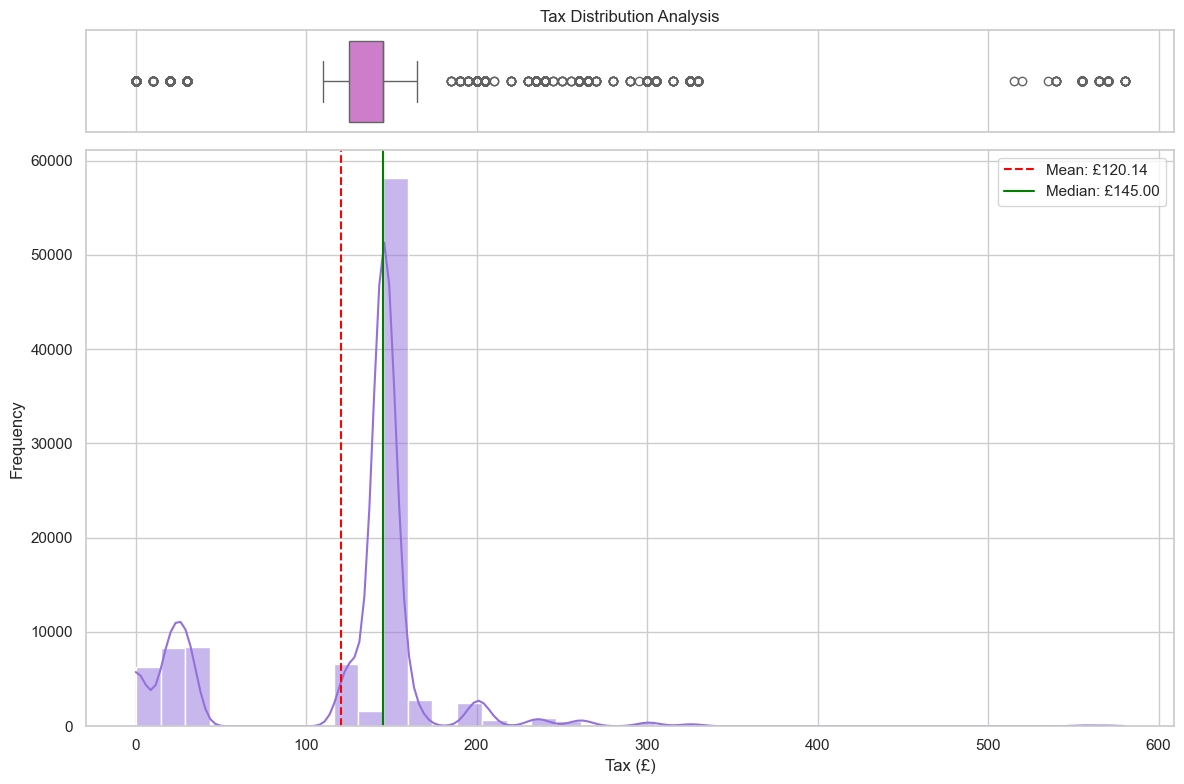

In [184]:
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (Boxplot on top, Histogram below)
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))

# Create the Box Plot
sns.boxplot(data=master_df, x='tax', ax=ax_box, color='orchid')
ax_box.set(title='Tax Distribution Analysis', xlabel='')

# Create the Histogram
sns.histplot(data=master_df, x='tax', kde=True, ax=ax_hist, color='mediumpurple', bins=40)
ax_hist.set(xlabel='Tax (£)', ylabel='Frequency')

# Add vertical lines for Mean and Median to evaluate the distribution
mean_tax = master_df['tax'].mean()
median_tax = master_df['tax'].median()
plt.axvline(mean_tax, color='red', linestyle='--', label=f"Mean: £{mean_tax:.2f}")
plt.axvline(median_tax, color='green', linestyle='-', label=f"Median: £{median_tax:.2f}")

# Final layout adjustments
plt.legend()
plt.tight_layout()
plt.show()

From the two visualizations we can clearly notice that:
- Most of the tax values are contained in the range 100-200, but
- There is a significant number of outliers, both for lower values (0-50) and for higher values (500-600).

We are proceeding with a more in-depth analysis to verify whether these outliers stem from data inconsistencies (such as data entry errors) or are factually correct, and to determine if these values align with our business case (mid-range car resale).

In [185]:
# Define the tax ranges as requested
# We use absolute filtering to avoid overlaps where specified
ranges = {
    '0 - 10':  master_df[(master_df['tax'] >= 0) & (master_df['tax'] <= 10)],
    '10 - 30': master_df[(master_df['tax'] > 10) & (master_df['tax'] <= 30)],
    '30 - 50': master_df[(master_df['tax'] > 30) & (master_df['tax'] <= 50)],
    'Over 500': master_df[master_df['tax'] > 500]
}

total_cars = len(master_df)

# Create a summary table
tax_analysis = []
for label, df_slice in ranges.items():
    count = len(df_slice)
    percentage = (count / total_cars) * 100
    tax_analysis.append({'Range (£)': label, 'Count': count, 'Percentage (%)': round(percentage, 2)})

tax_summary_df = pd.DataFrame(tax_analysis)
print(f"Tax Bracket Distribution (Total Cars: {total_cars})")
display(tax_summary_df)

Tax Bracket Distribution (Total Cars: 97712)


,Range (£),Count,Percentage (%)
0,0 - 10,6284,6.43
1,10 - 30,16671,17.06
2,30 - 50,0,0.00
3,Over 500,176,0.18


Based on the distribution table, we can observe a significant volume of vehicles with annual tax rates under £50 (accounting for nearly 24% of the dataset), contrasted by a much smaller segment of vehicles with taxes exceeding £500. Research into the British car taxation system system confirms that these values are factually correct and reflect specific historical tax regulations:
- Low Tax Range (£0 - £50): For vehicles registered before April 2017, tax rates were strictly based on $CO_2$ emissions, allowing low-emission cars (Band A, $<100\text{g/km}$) to qualify for a £0 rate and Band B cars to pay only £20.
- High Tax Range (> £500): These rates are typical for high-performance vehicles with large engine sizes emitting over $255\text{g/km}$ of $CO_2$ (Band M), or newer luxury cars with a list price over £40,000 that incur an "expensive car" supplement for five years.

Since we position ourselves as a mid-range dealer, we retain cars in the low tax range within the dataset, as they are certainly part of the dealer’s inventory. Conversely, we remove observations of vehicles with taxes exceeding £500 from the dataset, as they realistically do not belong to the sales portfolio and keeping them could introduce noise that disrupts the model’s predictive capability.

In [186]:
# 1. Remove cars with a tax higher than £500
initial_rows = len(master_df)
master_df = master_df[master_df['tax'] <= 500]

# 2. Calculate and output the impact of the cleaning
rows_deleted = initial_rows - len(master_df)
print(f"Cleaning step finished. Removed {rows_deleted} tax outliers.")
print(f"Current dataset size: {len(master_df)} rows.")

# 3. Final verification of the tax upper bound
print(f"New maximum tax value in the dataset: £{master_df['tax'].max()}")

Cleaning step finished. Removed 176 tax outliers.
Current dataset size: 97536 rows.
New maximum tax value in the dataset: £330.0


### Brand Feature

Let's move on to the analyzing brand: let's check if all the values are consistent.

In [187]:
# 1. Get the list of all unique brands
unique_brands = master_df['brand'].unique()

# 2. Get the count of observations for each brand to see the distribution
brand_distribution = master_df['brand'].value_counts()

# 3. Display the results
print("Unique brands in the dataset:")
print(unique_brands)
print("\nNumber of cars per brand:")
print(brand_distribution)

Unique brands in the dataset:
['audi' 'bmw' 'ford' 'hyundi' 'merc' 'skoda' 'toyota' 'vauxhall' 'vw']

Number of cars per brand:
brand
ford        17799
vw          14887
vauxhall    13253
merc        12791
bmw         10624
audi        10525
toyota       6696
skoda        6188
hyundi       4773
Name: count, dtype: int64


There are no duplicate car brands. Just for spelling purposes and overall clarity, some of the brands are renamed.

In [188]:
# 1. Create a mapping dictionary for the corrections
# Based on the unique values identified in the previous step
brand_mapping = {
    'vw': 'volkswagen',
    'hyundi': 'hyundai',
    'merc': 'mercedes'
}

# 2. Replace the values in the 'brand' column
master_df['brand'] = master_df['brand'].replace(brand_mapping)

# 3. Verify that the transformation was successful
print("Updated unique brands list:")
print(master_df['brand'].unique())

Updated unique brands list:
['audi' 'bmw' 'ford' 'hyundai' 'mercedes' 'skoda' 'toyota' 'vauxhall'
 'volkswagen']


### Engine Size

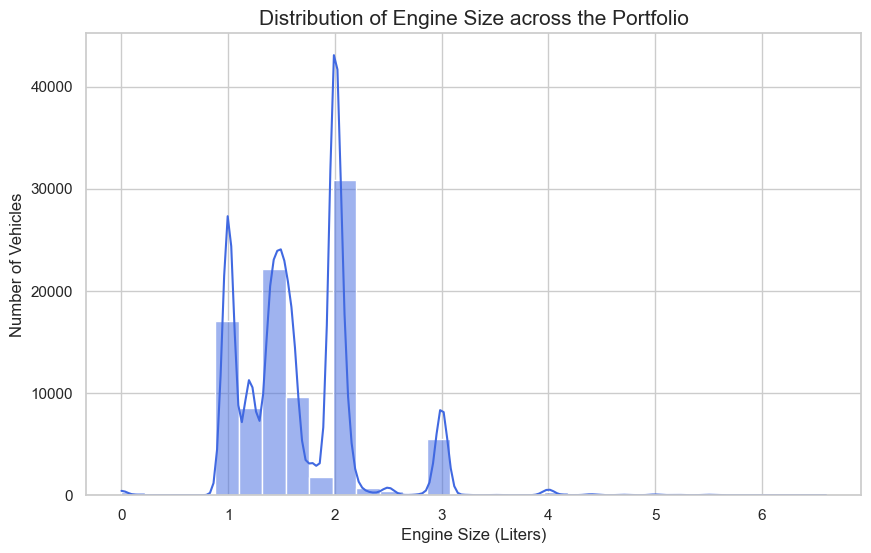

In [189]:
sns.set_theme(style="whitegrid")

# Create the histogram for engine size
plt.figure(figsize=(10, 6))
sns.histplot(master_df['enginesize'], bins=30, kde=True, color='royalblue')
plt.title('Distribution of Engine Size across the Portfolio', fontsize=15)
plt.xlabel('Engine Size (Liters)', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.show()

The histogram reveals that the majority of vehicles feature an engine size between 1.0 and 3.0 liters; we can also observe the presence of both lower and upper outliers. 

Based on technical research, engine sizes below 0.6 liters are considered impossible values: no car has an engine size lower than 0.6 liters. Since these erroneous records are minimal, they will be removed from the dataset.

In [190]:
# 1. Remove all records with engine size < 0.6
initial_count = len(master_df)
master_df = master_df[master_df['enginesize'] >= 0.6]

# 2. Calculate and print the impact of the cleaning
removed_rows = initial_count - len(master_df)
print(f"Rows removed: {removed_rows}")
print(f"New total observations: {len(master_df)}")

# 3. Verify new minimum engine size
print(f"New minimum engine size: {master_df['enginesize'].min()}L")

Rows removed: 266
New total observations: 97270
New minimum engine size: 0.6L


Regarding the upper outliers, we maintain a conservative approach: we are evaluating the removal of observations with engine sizes exceeding 5.0 liters, as they could impair the model's predictive capability. 

Before proceeding with the removal, we will verify whether these records correspond to luxury or high-end vehicles, which fall outside the target market of our mid-range business model.

In [191]:
# Block 2: Investigating very large engine sizes
# Filter for engine size above 5.0
large_engines = master_df[master_df['enginesize'] > 5.0]

print(f"Total records with engine size > 5.0: {len(large_engines)}")
if len(large_engines) > 0:
    # Display the models to check if they are high-performance vehicles (e.g., AMG, M-Series)
    display(large_engines[['brand', 'model', 'enginesize', 'fueltype']].value_counts().to_frame())
else:
    print("No records found in this range.")

Total records with engine size > 5.0: 46


count
brand    model     enginesize fueltype       
audi     R8        5.2        Petrol       18
mercedes GLE Class 5.5        Petrol       10
         SL CLASS  5.5        Petrol        9
         GLS Class 5.5        Petrol        3
bmw      7 Series  6.6        Petrol        2
mercedes G Class   5.5        Petrol        1
         CL Class  5.4        Petrol        1
         S Class   5.5        Petrol        1
                   6.0        Petrol        1

All car models shown in the table are high-end cars that don't fall into our target. We can therefore eliminate this rows without any doubt.

In [192]:
# Eliminate rows with engine size > 5 L
initial_rows = len(master_df)
master_df = master_df[master_df['enginesize'] <= 5.0]

# 2. Verify the result
removed_count = initial_rows - len(master_df)
print(f"Filtering complete. Removed {removed_count} luxury outliers (> 5.0L).")
print(f"Final dataset size: {len(master_df)} rows.")

# 3. Check the new maximum engine size
print(f"New maximum engine size: {master_df['enginesize'].max()}L")

Filtering complete. Removed 46 luxury outliers (> 5.0L).
Final dataset size: 97224 rows.
New maximum engine size: 5.0L


### Fuel Type

In [193]:
# 1. Get the list of all unique fuel types
unique_fuels = master_df['fueltype'].unique()

# 2. Get the count of observations for each fuel type
fuel_distribution = master_df['fueltype'].value_counts()

# 3. Display the results
print("Unique fuel types in the dataset:")
print(unique_fuels)
print("\nNumber of cars per fuel type:")
print(fuel_distribution)

Unique fuel types in the dataset:
['Petrol' 'Diesel' 'Hybrid' 'Other' 'Electric']

Number of cars per fuel type:
fueltype
Petrol      53638
Diesel      40316
Hybrid       3021
Other         245
Electric        4
Name: count, dtype: int64


The absolute frequency for electric vehicles is extremely low, with only four observations in the dataset. To ensure model robustness and prevent issues related to sparse data, electric vehicles have been aggregated into the 'Other' category.

In [194]:
# Merging 'Electric' into 'Other' due to very low frequency 
fuel_mapping = {
    'Electric': 'Other'
}

# 2. Apply the change to the fueltype column
master_df['fueltype'] = master_df['fueltype'].replace(fuel_mapping)

# 3. Verify the new distribution
print("Updated distribution of fuel types:")
print(master_df['fueltype'].value_counts())

Updated distribution of fuel types:
fueltype
Petrol    53638
Diesel    40316
Hybrid     3021
Other       249
Name: count, dtype: int64


### Trasmission

In [195]:
# 1. Get unique values and their absolute frequency
transmission_counts = master_df['transmission'].value_counts()

# 2. Calculate the percentage for each category
transmission_pct = master_df['transmission'].value_counts(normalize=True) * 100

# 3. Combine into a single summary table
transmission_summary = pd.DataFrame({
    'Count': transmission_counts,
    'Percentage (%)': transmission_pct.round(2)
})

# 4. Display the results
print("Transmission types and frequencies:")
display(transmission_summary)

Transmission types and frequencies:


,Count,Percentage (%)
transmission,,
Manual,55324,56.90
Semi-Auto,22234,22.87
Automatic,19658,20.22
Other,8,0.01


The frequency of the 'Other' category is so low that it is statistically irrelevant for our model. In this case as well, to ensure model robustness, we  remove these observations from the dataset.

In [196]:
# 1. Identify and remove rows where transmission is 'Other'
# Given there are only 8 such observations (0.01%), they are statistically insignificant
initial_count = len(master_df)
master_df = master_df[master_df['transmission'] != 'Other']

# 2. Calculate and print the impact
removed_rows = initial_count - len(master_df)
print(f"Rows removed (transmission 'Other'): {removed_rows}")
print(f"Final dataset size: {len(master_df)} rows")

# 3. Quick verification of remaining categories
print("\nRemaining transmission types:")
print(master_df['transmission'].value_counts())

Rows removed (transmission 'Other'): 8
Final dataset size: 97216 rows

Remaining transmission types:
transmission
Manual       55324
Semi-Auto    22234
Automatic    19658
Name: count, dtype: int64


### Miles per gallon

The first operation we perform with the 'miles per gallon' variable is to convert the values into kilometers per liter to facilitate interpretation, assuming the car dealer is from a country that uses the metric system, such as Portugal.

In [197]:
# 1. Define the conversion factor (UK Gallons to Liters and Miles to KM)
# 1 mile = 1.60934 km
# 1 gallon (UK) = 4.54609 liters
conversion_factor = 1.60934 / 4.54609

# 2. Create the new column 'km_l'
master_df['km_per_litre'] = master_df['mpg'] * conversion_factor
master_df['km_per_litre'] = master_df['km_per_litre'].astype(int)

# 3. Analyze extreme values for the new variable
print("Technical Overview of km_l:")
print(master_df['km_per_litre'].describe())

Technical Overview of km_l:
count    97216.000000
mean        19.012436
std          5.001017
min          0.000000
25%         16.000000
50%         19.000000
75%         22.000000
max        166.000000
Name: km_per_litre, dtype: float64


Next, we proceed to ensure that the values contained within the variable are realistic. Following our research, we concluded that even while maintaining a conservative approach, any value below 4 km/l or above 100 km/l is considered implausible. Let's check this hypothesis into the dataset

In [198]:
# 1. Define the feasible range limits
lower_limit = 4.0
upper_limit = 100.0

# 2. Identify rows outside the range
# We consider both the very low (errors) and the very high (impossible/extreme)
outliers_lower = master_df[master_df['km_per_litre'] < lower_limit]
outliers_upper = master_df[master_df['km_per_litre'] > upper_limit]

# 3. Calculate counts
count_low = len(outliers_lower)
count_high = len(outliers_upper)
total_outliers = count_low + count_high

# 4. Display the results
print(f"Analysis of Fuel Efficiency Outliers ({lower_limit} - {upper_limit} km/l):")
print(f"- Rows below {lower_limit} km/l: {count_low}")
print(f"- Rows above {upper_limit} km/l: {count_high}")
print(f"- Total rows to be removed: {total_outliers}")
print(f"- Impact on dataset: {(total_outliers / len(master_df) * 100):.4f}%")

# Show a sample of the most extreme values to confirm they are errors
if total_outliers > 0:
    print("\nSample of extreme outliers (sorted by km_l):")
    display(pd.concat([outliers_lower, outliers_upper]).sort_values(by='km_per_litre')[['brand', 'model', 'year', 'mpg', 'km_per_litre']].head(10))

Analysis of Fuel Efficiency Outliers (4.0 - 100.0 km/l):
- Rows below 4.0 km/l: 34
- Rows above 100.0 km/l: 8
- Total rows to be removed: 42
- Impact on dataset: 0.0432%

Sample of extreme outliers (sorted by km_l):


,brand,model,year,mpg,km_per_litre
40222,hyundai,Ioniq,2020,1.1,0
39624,hyundai,Ioniq,2019,1.1,0
70256,toyota,Hilux,2020,2.8,0
70255,toyota,Hilux,2019,2.8,0
70236,toyota,Hilux,2019,2.8,0
70235,toyota,Hilux,2019,2.8,0
70254,toyota,Hilux,2020,2.8,0
70243,toyota,Hilux,2019,2.8,0
70222,toyota,Hilux,2020,2.8,0
70223,toyota,Hilux,2020,2.8,0


In [199]:
display(outliers_upper[['brand', 'model', 'year', 'fueltype', 'mpg', 'km_per_litre']].sort_values(by='km_per_litre', ascending=False))

,brand,model,year,fueltype,mpg,km_per_litre
10700,bmw,i3,2016,Other,470.8,166
18856,bmw,i3,2015,Other,470.8,166
19288,bmw,i3,2017,Other,470.8,166
19503,bmw,i3,2015,Other,470.8,166
20748,bmw,i3,2017,Other,470.8,166
20754,bmw,i3,2017,Other,470.8,166
20993,bmw,i3,2016,Other,470.8,166
21198,bmw,i3,2017,Other,470.8,166


Observations with fuel efficiency values below 4 km/l are clearly erroneous and will be removed. Regarding the vehicles with values exceeding 100 km/l, we discovered that they all belong to a single model (BMW i3), which can realistically achieve up to 166 km/l. However, we have chosen to exclude these observations from the dataset as well; as extreme outliers, they could compromise the model's predictive performance.

In [200]:
# Removing both lower and upper outliers
initial_count = len(master_df)

# Applying fuel efficiency limits (4.0 - 100.0 km/l)
master_df = master_df[(master_df['km_per_litre'] >= 4.0) & (master_df['km_per_litre'] <= 100.0)]

# 2. Final verification
removed_total = initial_count - len(master_df)
print(f"Cleaning complete. Total rows removed in this step: {removed_total}")
print(f"Final dataset size: {len(master_df)} rows")

# 3. Check new max/min values to ensure consistency
print("\nFinal Bounds Check:")
print(f"- Year Range: {master_df['year'].min()} to {master_df['year'].max()}")
print(f"- Efficiency Range: {master_df['km_per_litre'].min():.2f} to {master_df['km_per_litre'].max():.2f} km/l")

Cleaning complete. Total rows removed in this step: 42
Final dataset size: 97174 rows

Final Bounds Check:
- Year Range: 1970 to 2060
- Efficiency Range: 6.00 to 90.00 km/l


In [201]:
# Remove the redundant 'mpg' column since we successfully converted it to 'km_l'
master_df = master_df.drop(columns=['mpg'])

# Verify the current columns in the dataframe
print("Updated list of columns:")
print(master_df.columns.tolist())

Updated list of columns:
['model', 'year', 'price', 'transmission', 'mileage', 'fueltype', 'tax', 'enginesize', 'brand', 'km_per_litre']


### Year

The dataset was published in 2020. Any observation with year hugher than that is clearly wrong and should be removed.

In [202]:
# 1. Locate the observation(s) with impossible years
future_cars = master_df[master_df['year'] > 2020]

print(f"Number of cars from the future: {len(future_cars)}")
display(future_cars)

Number of cars from the future: 1


,model,year,price,transmission,mileage,fueltype,tax,enginesize,brand,km_per_litre
39175,Fiesta,2060,6495,Automatic,54807,Petrol,205.0,1.4,ford,15


In [203]:
# 2. Remove them from the dataset
master_df = master_df[master_df['year'] <= 2020]

# 3. Verify the new maximum year
print(f"New maximum year in dataset: {master_df['year'].max()}")

New maximum year in dataset: 2020


Let's now visualize the distribution of years using an histogram

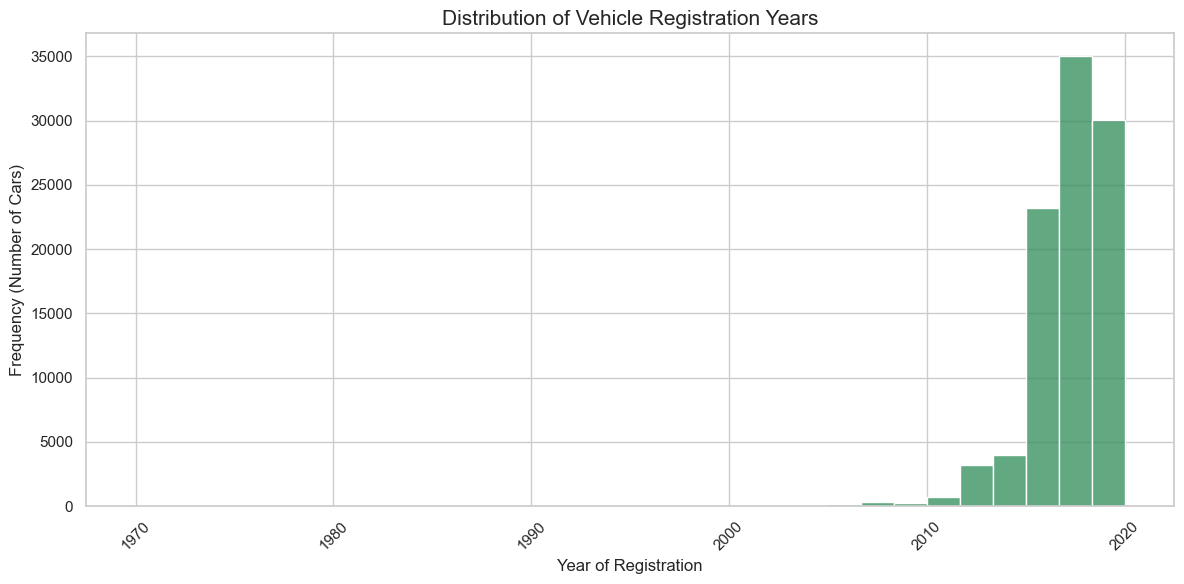

In [204]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(master_df['year'], bins=30, kde=False, color='seagreen')
plt.title('Distribution of Vehicle Registration Years', fontsize=15)
plt.xlabel('Year of Registration', fontsize=12)
plt.ylabel('Frequency (Number of Cars)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The dataset includes vehicles dating back to 1970; however, as observed, cars manufactured before 2010 are extremely rare. To ensure model robustness, it may be advisable to remove observations prior to this year. Nevertheless, before proceeding with any removal, we will verify the actual frequency of these older vehicles to assess their impact.

In [205]:
# 1. Split the dataset into two groups: pre-2010 and post-2010
pre_2010 = master_df[master_df['year'] < 2010]
post_2010 = master_df[master_df['year'] >= 2010]

# 2. Calculate absolute frequencies and percentages
count_pre = len(pre_2010)
count_post = len(post_2010)
total = len(master_df)

# 3. Display the results
print(f"Analysis of Vehicle Age Distribution:")
print(f"- Cars produced BEFORE 2010: {count_pre} ({(count_pre/total*100):.2f}%)")
print(f"- Cars produced FROM 2010 onwards: {count_post} ({(count_post/total*100):.2f}%)")

Analysis of Vehicle Age Distribution:
- Cars produced BEFORE 2010: 905 (0.93%)
- Cars produced FROM 2010 onwards: 96268 (99.07%)


As we can see the percentage of observations prior to 2010 is very low: we can confidently remove these observations from the dataset.

In [206]:
# 1. Keep only vehicles registered from 2010 onwards
# This removes 958 rows identified as noise (0.98% of the total)
initial_rows = len(master_df)
master_df = master_df[master_df['year'] >= 2010]

# 2. Calculate the impact of this operation
deleted_rows = initial_rows - len(master_df)
print(f"Cleaning complete: {deleted_rows} older records removed.")
print(f"Final dataset consistency: {len(master_df)} total observations.")

# 3. Quick check to verify the new temporal boundaries
print(f"New temporal range: {master_df['year'].min()} to {master_df['year'].max()}")

Cleaning complete: 905 older records removed.
Final dataset consistency: 96268 total observations.
New temporal range: 2010 to 2020


### Price

Price is the most important variable in the dataset, serving as the dependent variable that the model will seek to predict. To understand the price distribution, we utilize a combination of a histogram and a box plot.

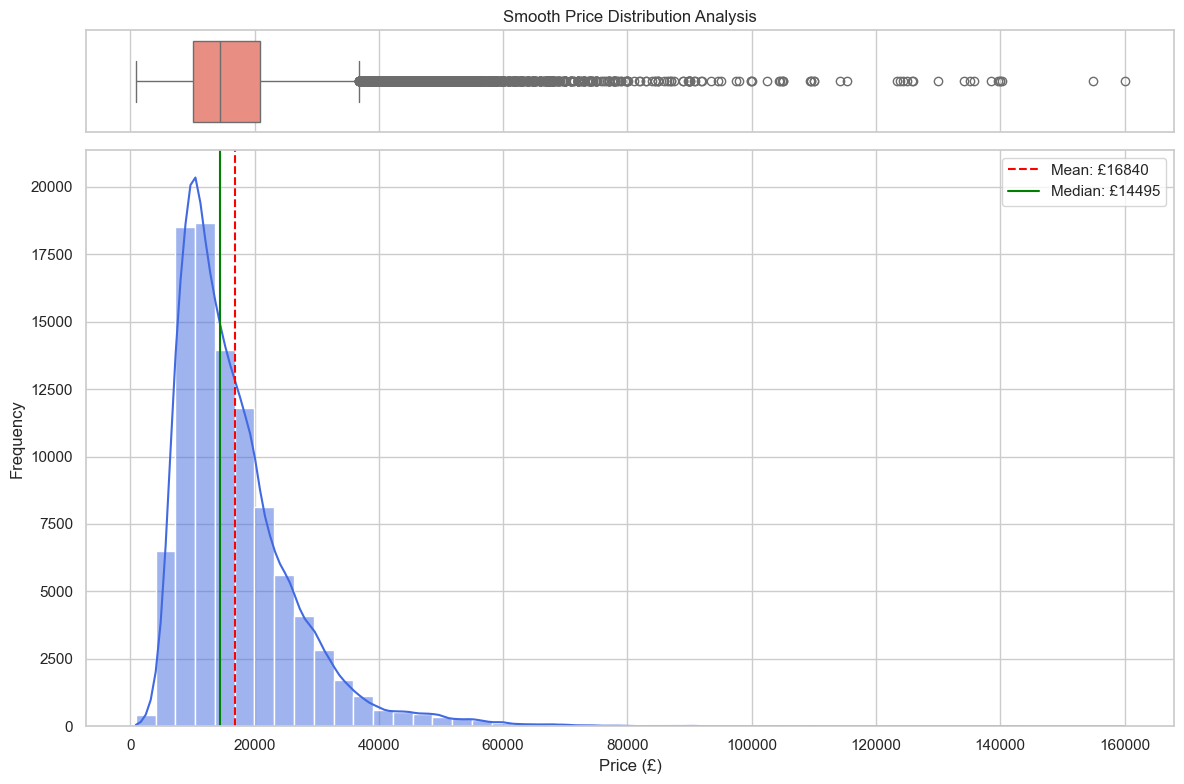

In [207]:

sns.set_theme(style="whitegrid")
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))
sns.boxplot(data=master_df, x='price', ax=ax_box, color='salmon')
ax_box.set(title='Smooth Price Distribution Analysis', xlabel='')
sns.histplot(data=master_df, x='price', kde=True, ax=ax_hist, color='royalblue', bins=50)
ax_hist.set(xlabel='Price (£)', ylabel='Frequency')
mean_p = master_df['price'].mean()
median_p = master_df['price'].median()
plt.axvline(mean_p, color='red', linestyle='--', label=f"Mean: £{mean_p:.0f}")
plt.axvline(median_p, color='green', linestyle='-', label=f"Median: £{median_p:.0f}")
plt.legend()
plt.tight_layout()
plt.show()

The histogram reveals that the price distribution is heavily right-skewed; the majority of vehicles in the dataset have a relatively low selling price, below £20,000,—followed by a very long right tail for higher values. The impact of this tail is significant, as evidenced by the fact that the mean (£16,840) is substantially higher than the median (£14,495).

For our business case, which focuses on mid-range vehicles, this long positive tail presents a challenge. It is considered best practice to exclude vehicles with excessively high prices, as they can introduce significant noise and compromise the model's predictive performance. Consequently, we will evaluate various thresholds (£50,000, £60,000, £80,000, and £100,000) to determine the volume of observations affected and find the optimal balance for data filtering.

In [208]:
# 1. Define the possible upper thresholds
thresholds = [50000, 60000, 80000, 100000]

# 2. Loop through thresholds to see the impact
for t in thresholds:
    count = len(master_df[master_df['price'] > t])
    percentage = (count / len(master_df)) * 100
    print(f"Cars above £{t}: {count} ({percentage:.2f}%)")

Cars above £50000: 1076 (1.12%)
Cars above £60000: 374 (0.39%)
Cars above £80000: 69 (0.07%)
Cars above £100000: 31 (0.03%)


We can observe that the percentage of vehicles exceeding these thresholds is remarkably low; even at the lowest threshold (£50,000), only 1.12% of the observations exceed this value. To ensure model robustness without excessively reducing the dataset's size, we have decided to remove all observations above £50,000. 

In [209]:
# 1. Filter the dataset by price: removing rows below 50000£
initial_count = len(master_df)
master_df = master_df[(master_df['price'] <= 50000)]

# 2. Calculate and print the impact
removed_rows = initial_count - len(master_df)
print(f"Price cleaning complete. Total rows removed: {removed_rows}")
print(f"Final dataset size: {len(master_df)} rows.")

# 3. Verify the final price boundaries
print(f"Final price range: £{master_df['price'].min()} - £{master_df['price'].max()}")

Price cleaning complete. Total rows removed: 1076
Final dataset size: 95192 rows.
Final price range: £900 - £50000


### Mileage

Similarly to what was done for the 'miles per gallon' variable (subsequently converted to km/l), we are converting 'mileage' into kilometers and renaming it mileage_km for enhanced clarity.

In [210]:
# 1. Convert mileage from miles to kilometers
# Conversion factor: 1 mile = 1.609344 km
master_df['mileage_km'] = master_df['mileage'] * 1.609344

# 2. Transform the float values into integers
# We remove decimals as they are not significant for mileage analysis
master_df['mileage_km'] = master_df['mileage_km'].astype(int)

# 3. Remove the original 'mileage' column to maintain a clean dataset
master_df = master_df.drop(columns=['mileage'])

# 4. Verify the transformation
print("Column successfully converted, rounded to integer, and renamed to 'mileage_km'.")
display(master_df[['brand', 'model', 'year', 'mileage_km']].head())

Column successfully converted, rounded to integer, and renamed to 'mileage_km'.


,brand,model,year,mileage_km
0,audi,A1,2017,25323
1,audi,A6,2016,58263
2,audi,A1,2016,48193
3,audi,A4,2017,41765
4,audi,A3,2019,3215


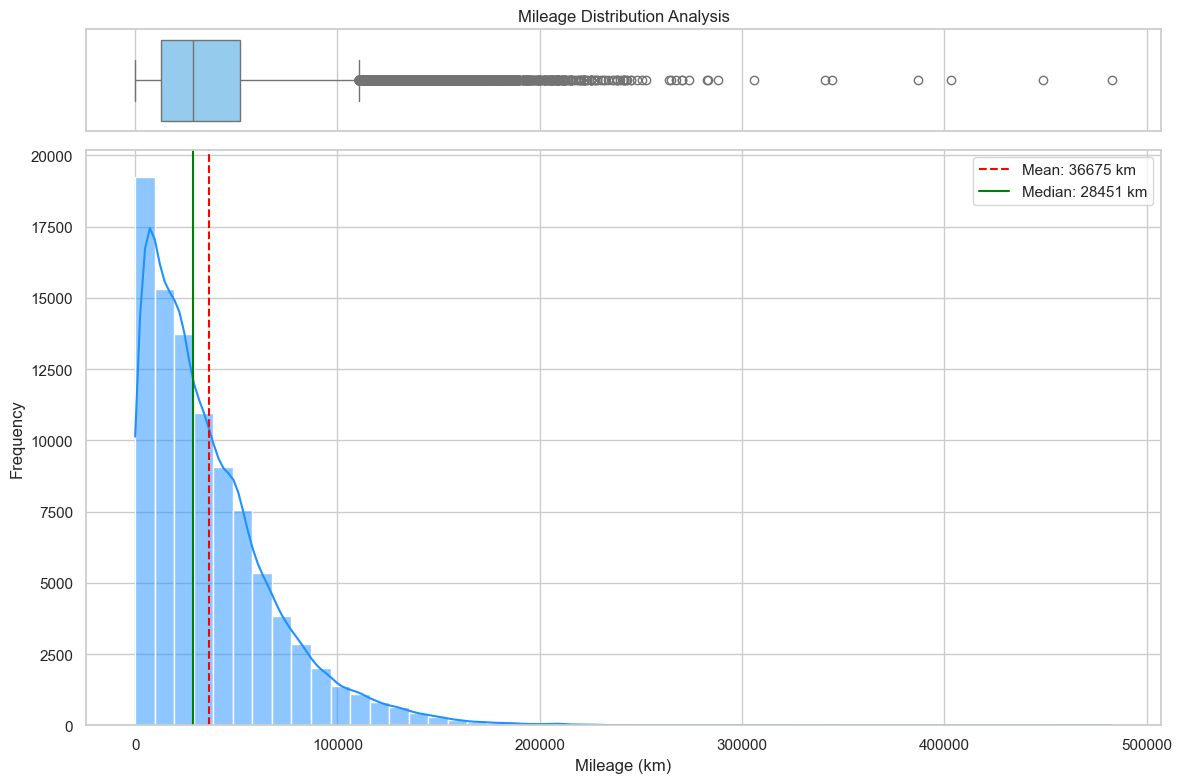

In [211]:
# Histogram and boxplot for mileage
sns.set_theme(style="whitegrid")
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))
sns.boxplot(data=master_df, x='mileage_km', ax=ax_box, color='lightskyblue')
ax_box.set(title='Mileage Distribution Analysis', xlabel='')
sns.histplot(data=master_df, x='mileage_km', kde=True, ax=ax_hist, color='dodgerblue', bins=50)
ax_hist.set(xlabel='Mileage (km)', ylabel='Frequency')
mean_m = master_df['mileage_km'].mean()
median_m = master_df['mileage_km'].median()
plt.axvline(mean_m, color='red', linestyle='--', label=f"Mean: {mean_m:.0f} km")
plt.axvline(median_m, color='green', linestyle='-', label=f"Median: {median_m:.0f} km")
plt.legend()
plt.tight_layout()
plt.show()

In this instance as well, we observe an extremely right-skewed distribution; the majority of vehicles in the dataset exhibit very low mileage, followed by a very long right tail of higher values. This tail has a significant impact, as evidenced by the mean (36,675 km) being considerably higher than the median (28,451 km).

For our business case, it is once again logical to exclude these extreme values for two reasons: 1) they introduce potential noise into the model, and 2) vehicles with excessively high mileage are essentially 'junk' that a reputable used car dealer would unlikely include in their inventory. Adopting a conservative approach to preserve the majority of the data, we will verify the percentage of records exceeding 150,000 km; if the proportion is low, we will remove these observations without hesitation.

In [212]:
# 1. Filter the dataset for cars with more than 150,000 km
km_threshold = 150000
very_high_mileage = master_df[master_df['mileage_km'] > km_threshold]

# 2. Calculate absolute and percentage frequency
count_extreme = len(very_high_mileage)
total_rows = len(master_df)
percentage_extreme = (count_extreme / total_rows) * 100

# 3. Print the results
print(f"Analysis of vehicles with > {km_threshold:,} km:")
print(f"- Absolute frequency: {count_extreme} cars")
print(f"- Percentage of dataset: {percentage_extreme:.2f}%")

Analysis of vehicles with > 150,000 km:
- Absolute frequency: 752 cars
- Percentage of dataset: 0.79%


The percentage of cars with mileage > 150.000 km is very low. We can eliminate this rows without any problem.

In [213]:
# 1. Remove cars with mileage greater than 150,000 km
# These are considered extreme outliers that could distort the regression model
initial_rows = len(master_df)
master_df = master_df[master_df['mileage_km'] <= 150000]

# 2. Calculate and print the impact of the cleaning
deleted_count = initial_rows - len(master_df)
print(f"Mileage cleaning complete. Removed {deleted_count} rows with > 150,000 km.")
print(f"New dataset size: {len(master_df)} observations.")

# 3. Final verification of the mileage range
print(f"Current mileage_km range: {master_df['mileage_km'].min()} - {master_df['mileage_km'].max()} km")

Mileage cleaning complete. Removed 752 rows with > 150,000 km.
New dataset size: 94440 observations.
Current mileage_km range: 1 - 149979 km


### Visualizing the final dataset

Now that the data cleaning and univariate analysis of the variables in the dataset is over, let's have a look at the final dataset.

In [214]:
# 1. Calculate the final state metrics
# We get the total number of rows to calculate percentages accurately
total_rows_clean = len(master_df)

# 2. Build the complete overview dictionary
# This includes the original columns plus the 3 requested for missing data
final_overview_data = {
    'Data Type': master_df.dtypes,
    'Total Observations': master_df.count(), # Non-null count
    'Missing Values (NaNs)': master_df.isna().sum(),
    '% Missing Values': (master_df.isna().sum() / total_rows_clean) * 100,
    'Unique Observations': master_df.nunique(),
    'Min Value': master_df.min(numeric_only=True),
    'Max Value': master_df.max(numeric_only=True)
}

# 3. Create the summary DataFrame
tech_overview_final = pd.DataFrame(final_overview_data)

# 4. Formatting for a professional look
# We ensure the percentage is readable and fill placeholders for non-numeric columns
tech_overview_final['% Missing Values'] = tech_overview_final['% Missing Values'].round(2).astype(str) + '%'
tech_overview_final['Min Value'] = tech_overview_final['Min Value'].fillna('-')
tech_overview_final['Max Value'] = tech_overview_final['Max Value'].fillna('-')

# 5. Display the result
print(f"Final dataset consistency check - Total rows: {total_rows_clean}")
tech_overview_final

Final dataset consistency check - Total rows: 94440


,Data Type,Total Observations,Missing Values (NaNs),% Missing Values,Unique Observations,Min Value,Max Value
brand,object,94440,0,0.0%,9,-,-
enginesize,float64,94440,0,0.0%,26,1.0,5.0
fueltype,object,94440,0,0.0%,4,-,-
km_per_litre,int64,94440,0,0.0%,43,7.0,90.0
mileage_km,int64,94440,0,0.0%,41276,1.0,149979.0
model,object,94440,0,0.0%,174,-,-
price,int64,94440,0,0.0%,12391,1795.0,50000.0
tax,float64,94440,0,0.0%,35,0.0,330.0
transmission,object,94440,0,0.0%,3,-,-
year,int64,94440,0,0.0%,11,2010.0,2020.0


In [215]:
# Export the final cleaned DataFrame to a CSV file
# We use index=False to avoid saving the row numbers as an extra column
master_df.to_csv('cleaned_car_data.csv', index=False)

# Confirmation message
print("Success! The file 'cleaned_car_data.csv' has been created and is ready for use.")

Success! The file 'cleaned_car_data.csv' has been created and is ready for use.


### Heatmap for numeric features

We now proceed to the multivariate analysis. In this section, we focus on examining the relationships between Price (our target variable) and the other features in the dataset. Our primary objective is to identify the most significant price drivers that will inform and optimize our predictive model.

We begin our analysis with a heatmap to visualize the correlation coefficients between the various numerical variables in the dataset. A heatmap is valuable for two primary reasons:
- Insight into Strength and Direction: It reveals how strongly and in what direction each variable relates to the price. Features with high absolute correlation values are likely to be the most significant predictors in our model.
- Identifying Multicollinearity: It highlights potential issues where independent variables are too closely related. A high correlation between two predictors can signal a multicollinearity problem that may destabilize the model.

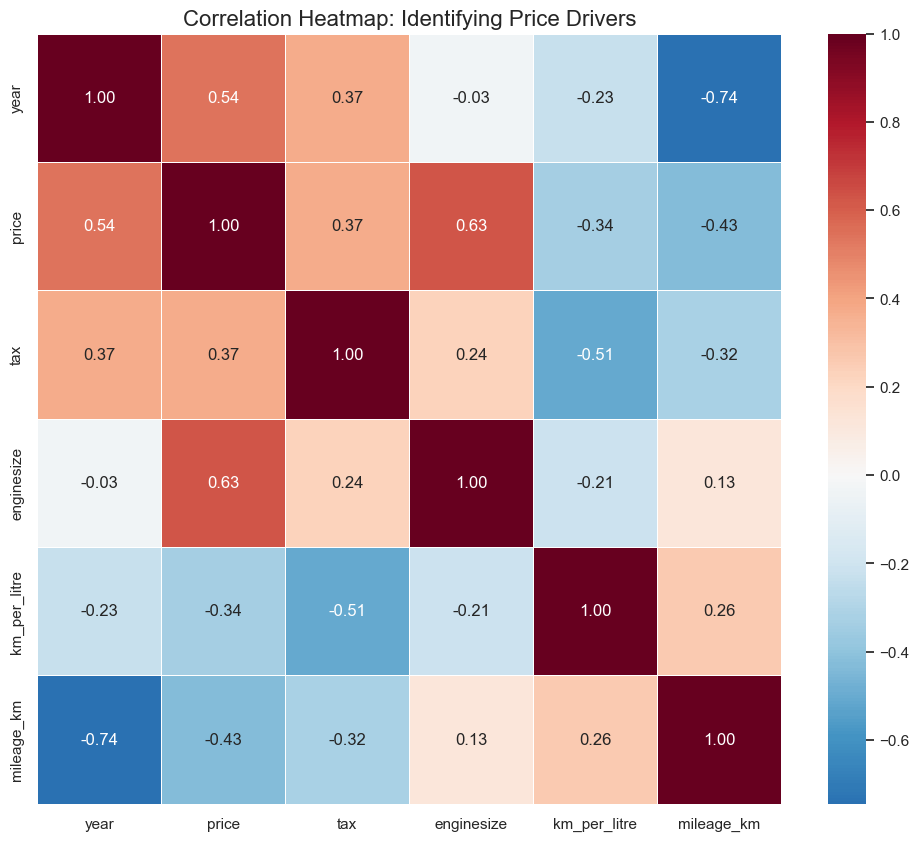

In [221]:
# 1. Calculate the correlation matrix
# We focus only on numeric variables to identify linear relationships
corr_matrix = master_df.corr(numeric_only=True)

# 2. Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,        
            cmap='RdBu_r',       
            center=0,            
            fmt=".2f", 
            linewidths=0.5)

plt.title('Correlation Heatmap: Identifying Price Drivers', fontsize=16)
plt.show()

Based on the heatmap, we can observe the following:
- Price Drivers: In relation to price, the features exhibiting the strongest correlations are enginesize ($r = 0.63$), year ($r = 0.54$), and mileage_km ($r = -0.43$). We anticipate that these features will be the most significant predictors in our final model.
- Potential Multicollinearity: The heatmap highlights a strong correlation between year and mileage_km ($r = -0.74$). Absolute values exceeding 0.7 are generally considered early indicators of high multicollinearity.To formally verify that multicollinearity does not compromise the model's integrity, we will calculate the Variance Inflation Factor (VIF) for the model's features. A VIF > 5 indicates significant multicollinearity, which would require corrective measures to ensure the stability of the regression coefficients.

In [223]:
# 1. Select the independent numerical variables
# We exclude 'price' because VIF measures multicollinearity among predictors
features = master_df[['year', 'mileage_km', 'tax', 'km_per_litre', 'enginesize']]

# 2. Add a constant (intercept)
# Statsmodels requires an explicit intercept to calculate VIF correctly
X = add_constant(features)

# 3. Calculate VIF for each feature
vif_info = pd.DataFrame()
vif_info["Feature"] = X.columns
vif_info["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Display the results (dropping the constant row for a cleaner view)
print("Variance Inflation Factor (VIF) Analysis:")
display(vif_info[vif_info['Feature'] != 'const'].sort_values(by="VIF", ascending=False))

Variance Inflation Factor (VIF) Analysis:


,Feature,VIF
2,mileage_km,2.374830
1,year,2.360036
3,tax,1.548884
4,km_per_litre,1.402441
5,enginesize,1.134317


The VIF analysis results are highly positive, as none of the variables exhibit critical values. In particular, mileage_km and year, which were identified as potentially problematic predictors due to their prior correlation, show VIF values well within the acceptable range. Consequently, there is no need to implement any corrective measures.

### Boxplot analysis for categorical features

### Price distribution by brand

C:\Users\filip\AppData\Local\Temp\ipykernel_11912\1425942641.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df,


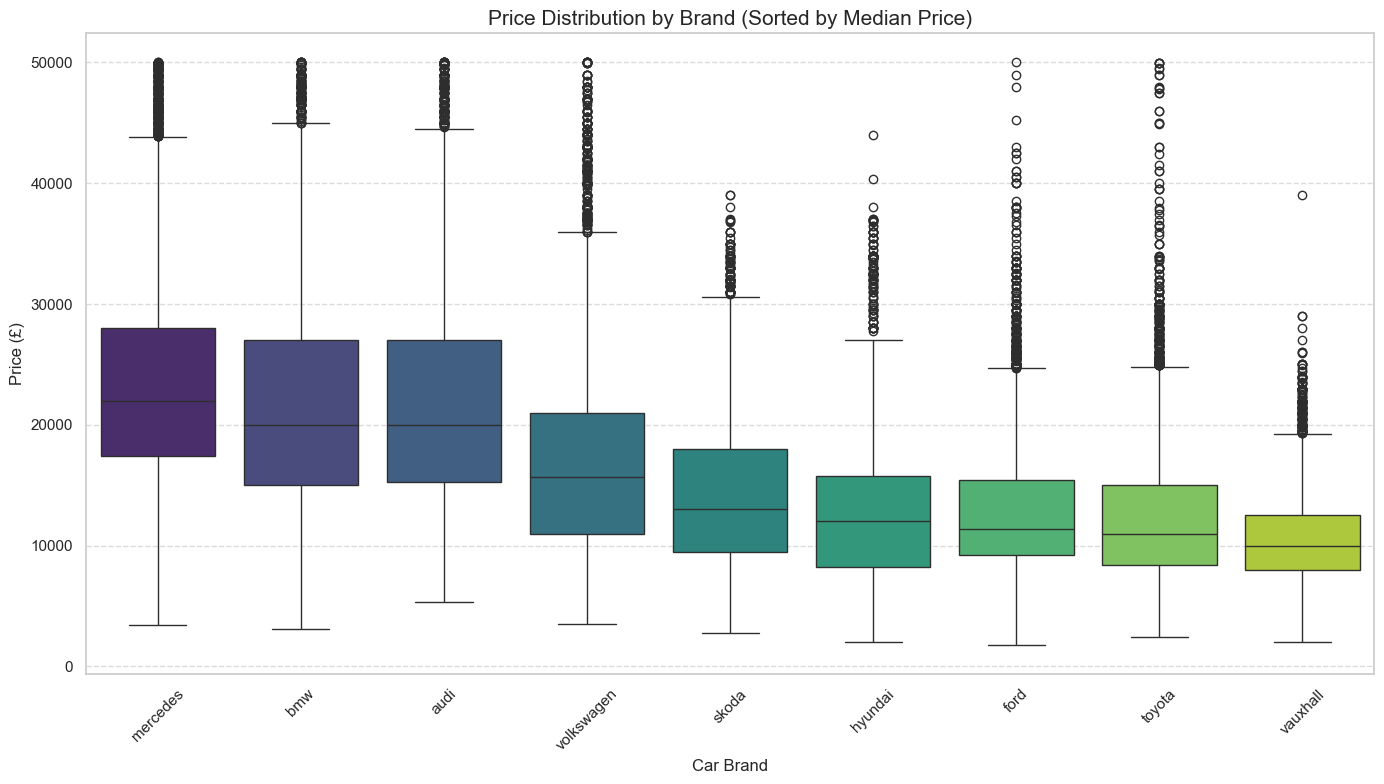

In [224]:
# 1. Set the order by median price 
brand_order = master_df.groupby('brand')['price'].median().sort_values(ascending=False).index

# 2. Create the boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=master_df, 
            x='brand', 
            y='price', 
            order=brand_order, 
            palette='viridis')

# 3. Refine the aesthetics
plt.xticks(rotation=45)
plt.title('Price Distribution by Brand (Sorted by Median Price)', fontsize=15)
plt.xlabel('Car Brand', fontsize=12)
plt.ylabel('Price (£)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The box plots reveal that brands could be effectively categorized into two distinct groups based on price:
- Premium Brands: BMW, Audi, and Mercedes show higher median prices and significantly greater price dispersion, as evidenced by their larger boxes (IQR) and longer whiskers.
- Mass-Market Brands: The remaining manufacturers exhibit lower median prices and more concentrated price distributions.

### Price distribution by Fueltype

C:\Users\filip\AppData\Local\Temp\ipykernel_11912\1565813954.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df,


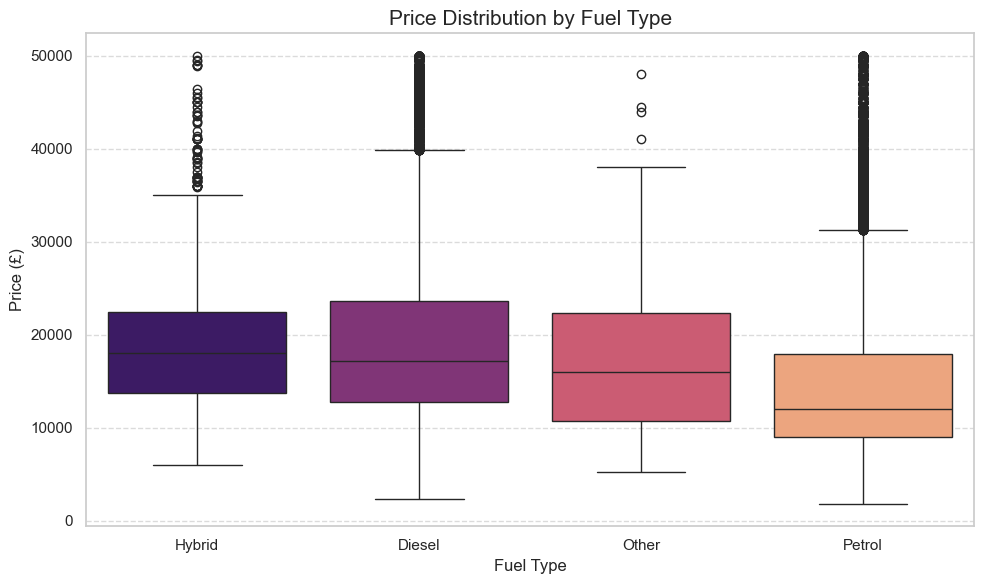

In [ ]:
# 1. Sort by median
fuel_order = master_df.groupby('fueltype')['price'].median().sort_values(ascending=False).index

# 2. Creating boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_df, 
            x='fueltype', 
            y='price', 
            order=fuel_order, 
            palette='magma')

# 3. Refining aestethics
plt.title('Price Distribution by Fuel Type', fontsize=15)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Price (£)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Regarding the price distribution by fuel type, we observe that:
- Petrol: Petrol vehicles exhibit lower median prices and a higher concentration in lower price ranges. This trend may be attributed to the fact that older vehicles in the dataset are predominantly petrol-powered, whereas newer models are increasingly hybrid or other alternative types.
- Hybrid, Diesel, and Other: These categories show very similar median values but significantly different dispersions. Diesel cars exhibit the greatest variance, while Hybrids show the least. This likely reflects the vast diversity within the Diesel segment, encompassing everything from mass-market to premium models, as well as a wide range of ages. On the other hand, Hybrid vehicles are generally newer and represent a more homogeneous technological segment.

C:\Users\filip\AppData\Local\Temp\ipykernel_11912\3742811299.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df,


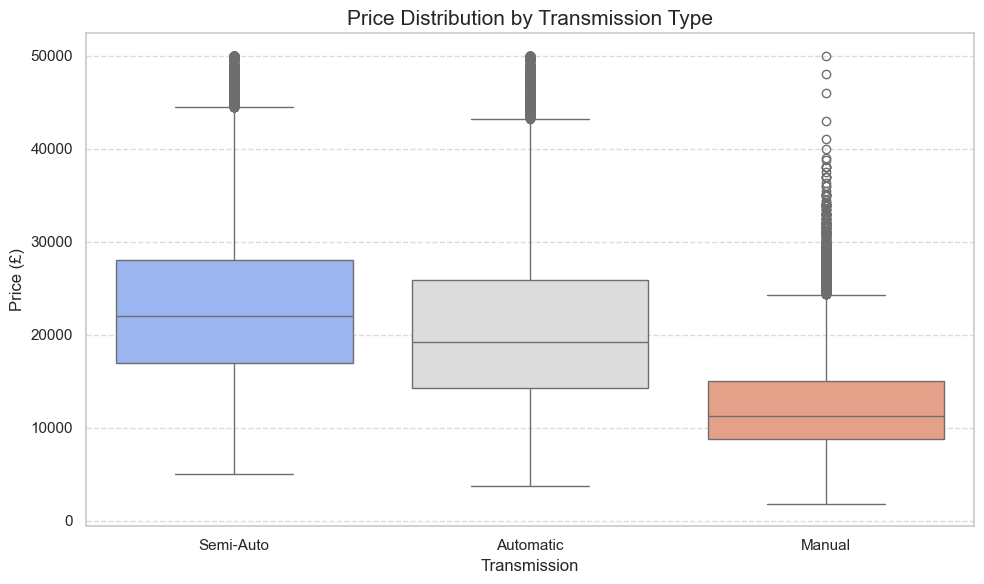

In [ ]:
# 1. Calculate the order based on median price
transmission_order = master_df.groupby('transmission')['price'].median().sort_values(ascending=False).index

# 2. Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_df, 
            x='transmission', 
            y='price', 
            order=transmission_order, 
            palette='coolwarm')

# 3. Aesthetics
plt.title('Price Distribution by Transmission Type', fontsize=15)
plt.xlabel('Transmission', fontsize=12)
plt.ylabel('Price (£)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Regarding transmission type, the vehicles can also be divided into two distinct groups:
- Automatic and Semi-Auto: These categories show very similar distributions, with aligned medians and comparable variances.
- Manual: These cars exhibit significantly lower median prices and much less dispersion. This finding is intuitive, as manual vehicles are often older or entry-level models, and therefore less expensive.

Given this differences, we expect trasmission type to be a very strong predictor for our model.